In [5]:
from randomness import *
from simulation_exact import *
from utils import *
from data_analysis import *
from main import *

begin intial training


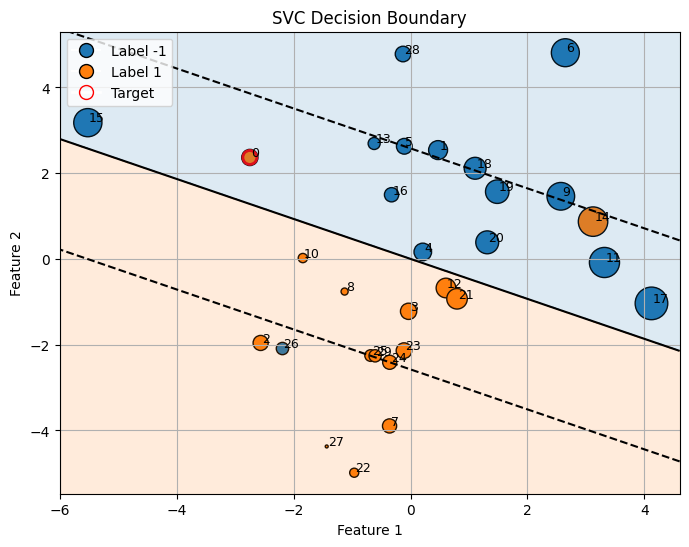

get relevant indcies
relevant indcies:  [ 3  4 11 12 15 17 19 20 21]
begin exact simulation
Number of non-zero payments: 2
Critical_v and True_v values:
   agent                                         x  critical_v     true_v
4     15   [-5.52370748092509, 3.1788778523202827]   36.588650  41.240867
5     17  [4.121781398718283, -1.0370906877579684]   20.178038  55.189218
exact sum: 56.766688132892305
exact util: 214.1729562634875
exact welfare: 270.9396443963798
Throw out points outside of 1+beta margin that are correctly classified
throw: [ 7 22 27 28]
train again


/home/sadi.bana/bana_project/accuracy_limited_resource/main.py:305: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  non_zero_df["x"] = non_zero_df["agent"].apply(lambda i: x[i])


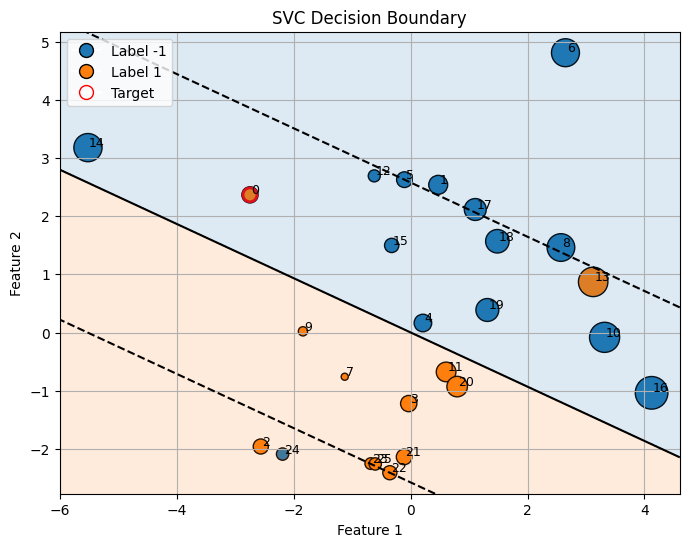

get relevant indcies
relevant indcies:  [ 3  4 10 11 14 16 18 19 20]
The models are equivelent
begin exact simulation for minimized model
Number of non-zero payments: 2
Critical_v and True_v values:
   agent                                         x  critical_v     true_v
4     14   [-5.52370748092509, 3.1788778523202827]   36.588650  41.240867
5     16  [4.121781398718283, -1.0370906877579684]   20.178038  55.189218
exact sum: 56.766688132892305
exact util: 214.1729562634875
exact welfare: 270.9396443963798


/home/sadi.bana/bana_project/accuracy_limited_resource/main.py:305: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  non_zero_df["x"] = non_zero_df["agent"].apply(lambda i: x[i])


In [6]:
n = 30
np.random.seed(42)
beta_1 = 1/(4*n)
beta_2 = -1/(4*n)
x, y, v = generate_data_centered(n) 
c = 1.0
M = np.sum(v)
use_loss = 'hinge' #'log' or 'hinge' or 'squared_hinge'
# v = np.ones(len(y))

print("begin intial training")
svm_model = train_soft_svm(x, y, v, c = (c/M), loss = use_loss)
plot_svm_decision_boundary(svm_model, x, y, v, 0)

print("get relevant indcies")
relevant_indcies = get_relevant_indices(svm_model, x, y, v, c/M)
print("relevant indcies: ", relevant_indcies)

print(f'begin exact simulation')
df_exact = main_exact(x, y, v, relevant_indcies, plot = False, c = (c/M), svm = train_soft_svm, loss = use_loss)
exact_sum = df_exact['critical_v'].sum()
exact_util = df_exact['utility'].sum()
exact_welfare = df_exact['welfare'].sum()
print(f'exact sum: {exact_sum}')
print(f'exact util: {exact_util}')
print(f'exact welfare: {exact_welfare}')

print("Throw out points outside of 1+beta margin that are correctly classified")
throw = get_outside_margins(svm_model, x, y, v, c = c/M)
print("throw:", throw)

if len(throw) > 0:
    mask = np.ones_like(v, dtype=bool)
    mask[throw] = False

    new_x = x[mask]
    new_y = y[mask]
    new_v = v[mask]

    print('train again')
    new_svm_model = train_soft_svm(new_x, new_y, new_v, c = (c/M), loss = use_loss)

    plot_svm_decision_boundary(new_svm_model, new_x, new_y, new_v, 0)

    print("get relevant indcies")
    relevant_indcies = get_relevant_indices(new_svm_model, new_x, new_y, new_v, c/M)
    print("relevant indcies: ", relevant_indcies)

    is_equ = models_equivalent(svm_model, new_svm_model)
    if is_equ:
        print("The models are equivelent")
    else:
        print("The models are NOT equivelent")

    print(f'begin exact simulation for minimized model')
    df_exact = main_exact(new_x, new_y, new_v, relevant_indcies, plot = False, c = (c/M), svm = train_soft_svm, loss = use_loss)
    exact_sum = df_exact['critical_v'].sum()
    exact_util = df_exact['utility'].sum()
    exact_welfare = df_exact['welfare'].sum()
    print(f'exact sum: {exact_sum}')
    print(f'exact util: {exact_util}')
    print(f'exact welfare: {exact_welfare}')

else:
    print("no throw")


###
# print("Throw out points outside of 1+beta margin that are correctly classified")
# new_x, new_y, new_v = get_outside_margins(svm_model, x, y, v, c = c/M)
# print("get relevant indcies")
# relevant_indcies = get_relevant_indices(svm_model, new_x, new_y, new_v, c/M)
# print(f'begin exact simulation')
# df_exact, model_1 = main_exact(new_x, new_y, new_v, relevant_indcies, plot = False, c = (c/M))
# exact_sum = df_exact['critical_v'].sum()
# exact_util = df_exact['utility'].sum()
# print(f'exact sum: {exact_sum}')
# print(f'exact util: {exact_util}')








